In [1]:
here::i_am("atac/archR/pseudobulk/2_archR_pseudobulk.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(scuttle))

library(uwot)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
      

In [2]:

## START TEST ##
args = list()
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_update_PeakClusters.txt.gz"
args$group_by <- "Clusters_PeakMatrix2"
args$matrices <- c("PeakMatrix")
args$threads <- 1
args$outdir <- "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/pseudobulk/Clusters_PeakMatrix2/PeakMatrix"
## END TEST ##

# Parse arguments
dir.create(args$outdir, showWarnings=F, recursive=T)

########################
## Load cell metadata ##
########################

cell_metadata.dt <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)]
stopifnot(args$group_by%in%colnames(cell_metadata.dt))
cell_metadata.dt <- cell_metadata.dt[!is.na(cell_metadata.dt[[args$group_by]])]

table(cell_metadata.dt[[args$group_by]])



  C1  C10  C11  C12  C13  C14  C15  C16  C17  C18  C19   C2  C20  C21  C22  C23 
 251  210 5809 2054  550 1997 5315 2976  364  891   54  403  954 1235  793  692 
 C24  C25   C3   C4   C5   C6   C7   C8   C9 
1830 2800  783 1011 1466  826 1288  498  486 

In [3]:
########################
## Load ArchR project ##
########################

# source(here::here("atac/archR/load_archR_project.R"))

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = 1)

# Subset
ArchRProject <- loadArchRProject(args$archr_directory)[cell_metadata.dt$cell]


Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [5]:
peakmatrix = getMatrixFromProject(ArchRProject, useMatrix = "PeakMatrix",binarize =TRUE, threads =14)

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-3310246500094-Date-2023-01-31_Time-09-53-07.log
If there is an issue, please report to github with logFile!

2023-01-31 09:55:34 : Organizing colData, 2.454 mins elapsed.

2023-01-31 09:55:35 : Organizing rowData, 2.468 mins elapsed.

2023-01-31 09:55:35 : Organizing rowRanges, 2.468 mins elapsed.

2023-01-31 09:55:35 : Organizing Assays (1 of 1), 2.469 mins elapsed.

2023-01-31 09:56:46 : Constructing SummarizedExperiment, 3.647 mins elapsed.

2023-01-31 09:57:36 : Finished Matrix Creation, 4.481 mins elapsed.



In [7]:
peakmatrix@assays@data$counts = peakmatrix@assays@data$PeakMatrix

In [12]:
library(scuttle)

ERROR: Error in library(biocparallel): there is no package called ‘biocparallel’


In [13]:
# pseudobulk binarized matrix
atac.pb = aggregateAcrossCells(peakmatrix, id = cell_metadata.dt$Clusters_PeakMatrix2, statistics='mean')

In [32]:
norm = log2(1e6*(sweep(atac.pb@assays@data$counts,2,colSums(atac.pb@assays@data$counts,na.rm=T),"/"))+1)

In [33]:
head(norm)

C1,C10,C11,C12,C13,C14,C15,C16,C17,C18,⋯,C23,C24,C25,C3,C4,C5,C6,C7,C8,C9
0.6684574,1.5970152,1.3857451,1.4289799,1.182590,1.3031373,1.4985570,1.4174291,1.4441129,1.1006685,⋯,1.3509355,1.5461466,1.0757415,1.2508046,1.3664035,1.3815512,1.6950346,1.4630010,1.3899657,1.349455
1.1234975,1.2327295,1.3609311,0.9014797,1.062422,1.0195983,1.0696366,1.0938996,0.7970561,1.2732474,⋯,1.1364053,0.8515795,1.1576224,0.8602092,1.2837980,1.0729770,1.4262950,0.8971902,1.2232460,1.211595
1.4689054,0.5360900,0.7914245,0.7607614,1.239119,0.8112992,0.6563029,0.7699672,0.8956728,0.9046042,⋯,0.7696851,0.8515795,0.9500675,0.7023517,0.6098401,0.6799249,0.8240804,0.5955730,0.4660757,0.472009
2.2722985,2.6265394,2.8609874,2.9539265,2.646339,2.8741788,3.1079280,2.9619347,2.8859876,2.6397381,⋯,2.5167247,2.5932245,2.4736077,2.4469975,2.5076639,2.8589153,3.2215251,3.2376706,2.9753083,3.101982
1.6148531,1.0875262,1.2785303,1.1332174,1.345935,1.0923336,1.1582314,1.1547703,0.6912006,1.4273700,⋯,1.3105059,0.9517590,1.3688124,0.8094853,1.0371574,1.1619266,1.9074486,0.7126757,1.5859583,1.829631
1.3065140,0.9260561,1.0920868,1.0296840,1.538419,1.1750359,0.9817319,1.2131764,0.4528864,1.4563129,⋯,1.3105059,0.9899610,1.3786021,1.1726860,0.7802224,1.3054998,1.7432584,0.8971902,1.4415160,1.663309


In [34]:
stats = data.table(idx = rowData(peakmatrix)$idx,
                  var = rowVars(norm),
                  mean = rowMeans(norm))

In [46]:
args$atac_matrix_cells <- '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds'

atac_cells.se <- readRDS(args$atac_matrix_cells)[,cell_metadata.dt$cell]
atac_cells.se
stats$feature = rownames(atac_cells.se)
rownames(peakmatrix) = rownames(atac_cells.se) 

class: RangedSummarizedExperiment 
dim: 238993 35536 
metadata(0):
assays(1): PeakMatrix
rownames(238993): chr1:3003473-3004073 chr1:3035580-3036180 ...
  chrX:169923276-169923876 chrX:169925415-169926015
rowData names(1): idx
colnames(35536): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [47]:
umap = fread(file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_None/umap_nfeatures25000_dims20_nneighbour25_mindist0.3.txt.gz'))
plot_acc = function(peak='chr1:3003473-3004073'){
    umap2 = cbind(umap, as.vector(assay(peakmatrix[peak, ])))
    umap2 = umap2[order(V2)]
    ggplot(umap2, aes(umap1, umap2, col=V2)) + 
        geom_point() + 
        viridis::scale_color_viridis(end=0, begin=1) + 
        theme_void()
}

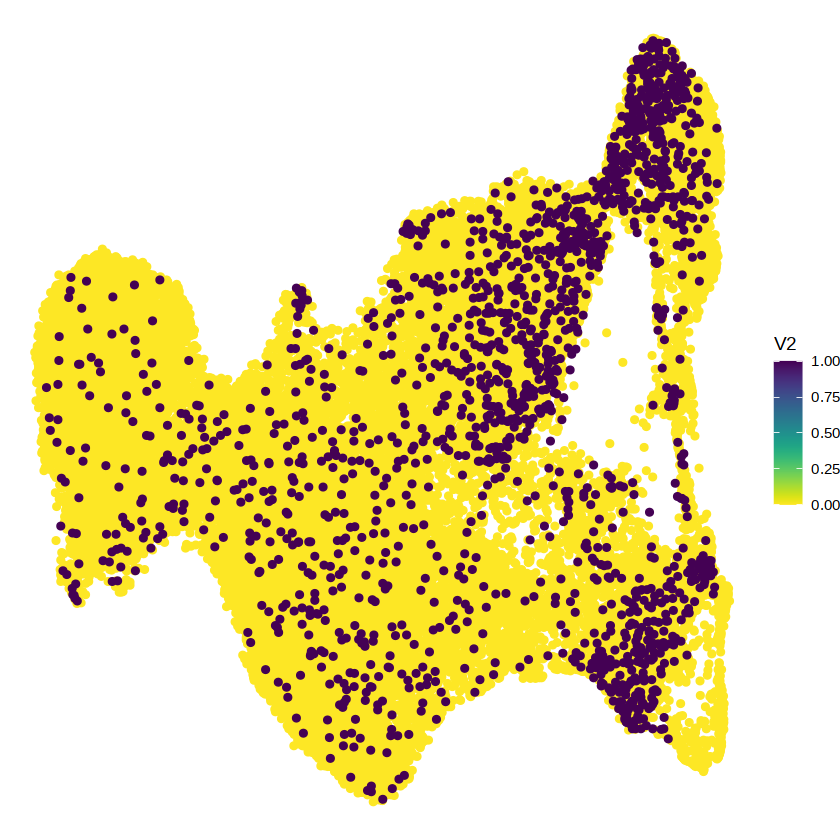

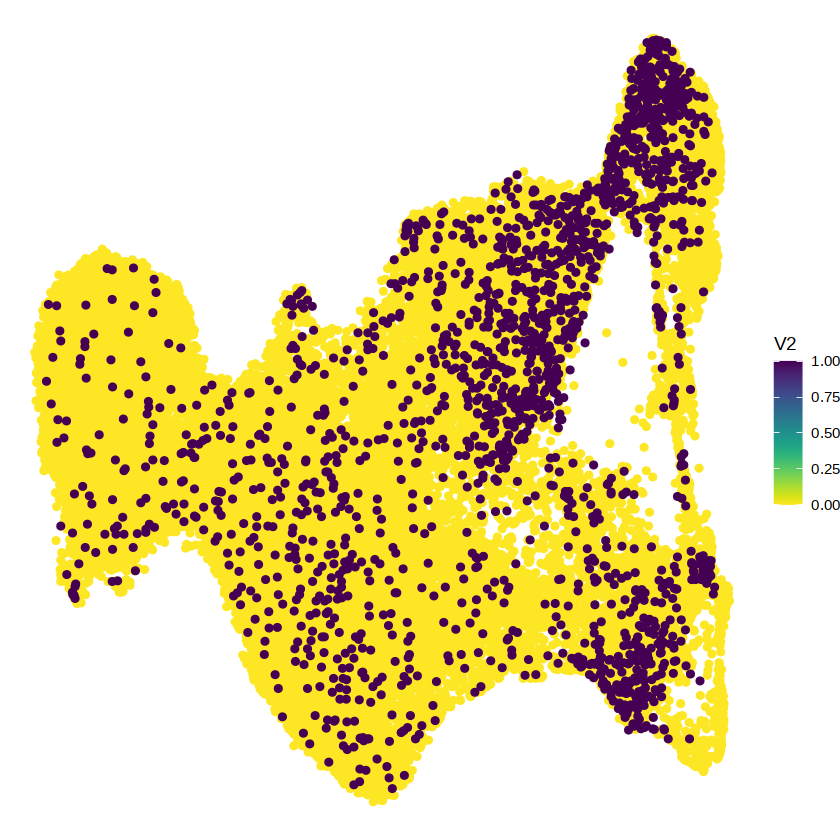

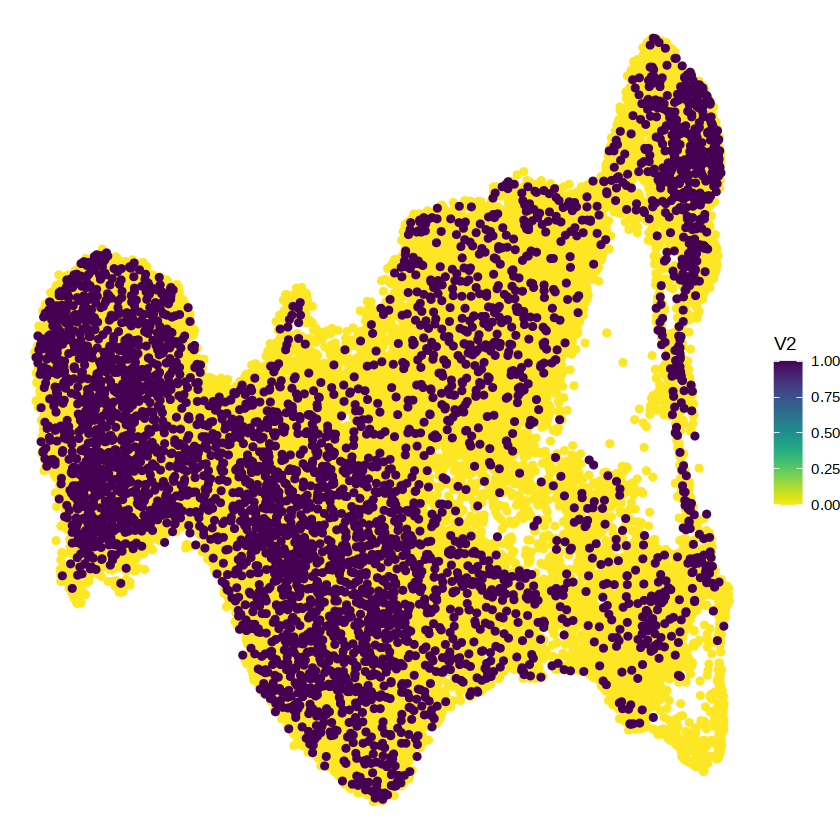

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


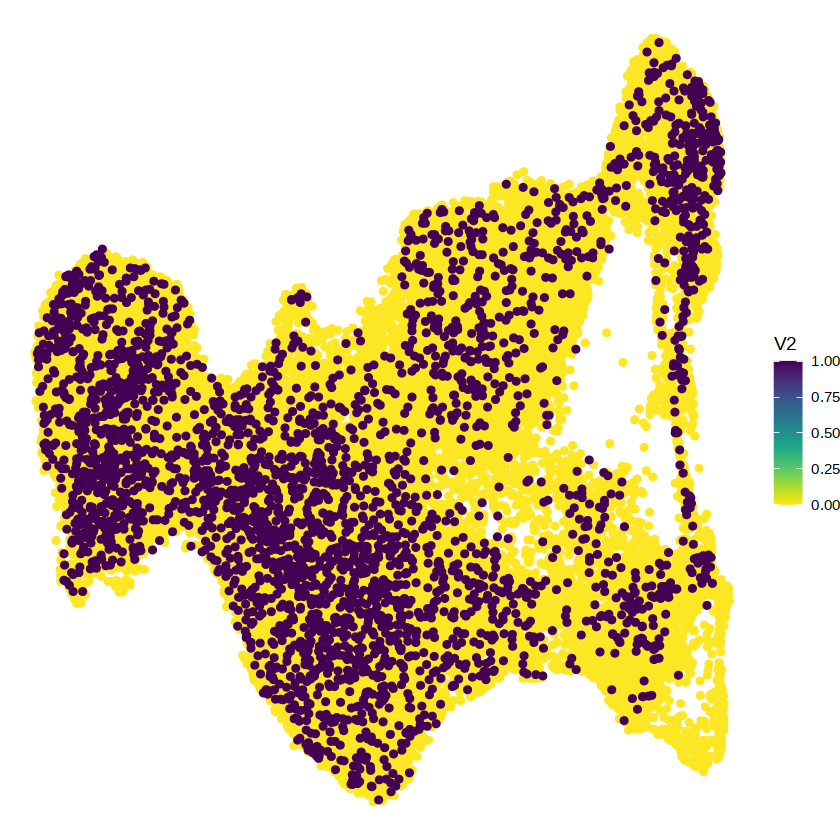

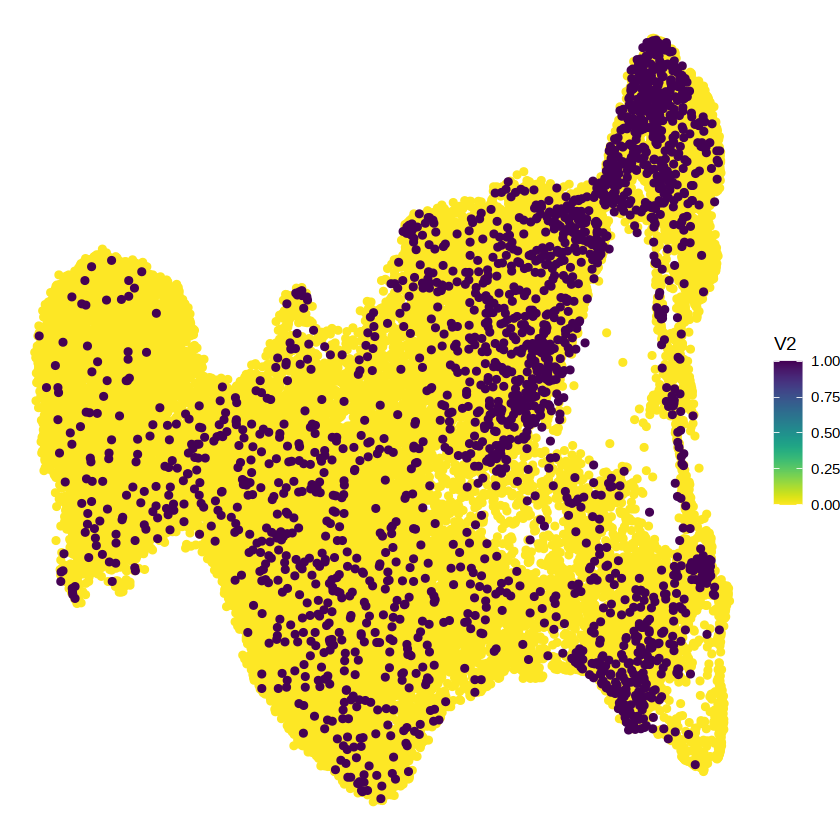

In [48]:
lapply(stats[order(-var), feature][1:5], plot_acc)

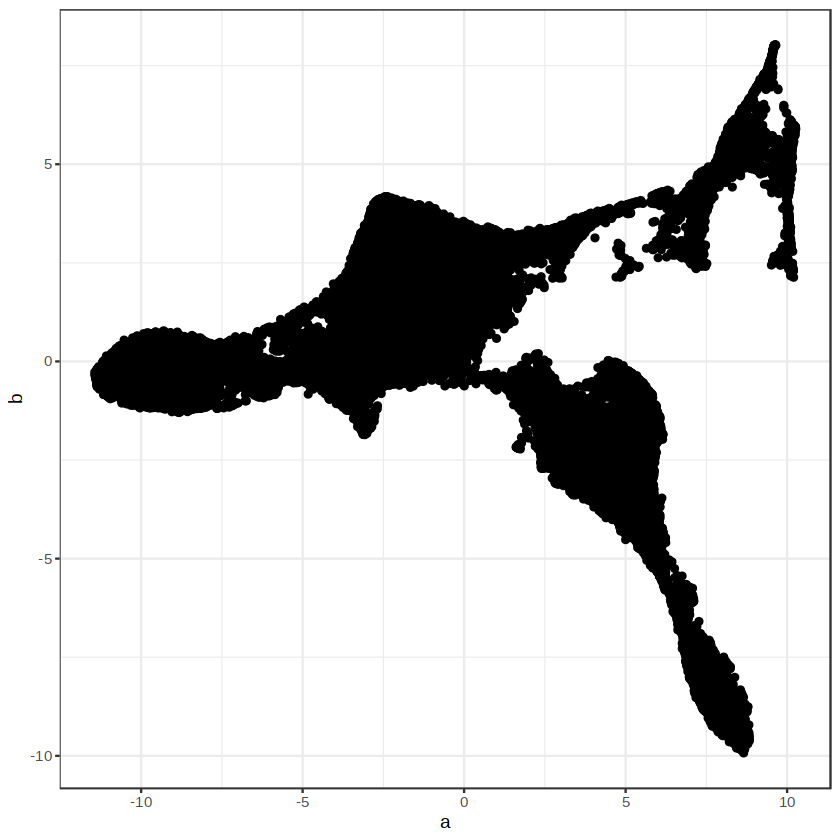

In [ ]:
# shape of umap mostly influenced by TF-IDF method being the wrong one
LSI = ArchR:::.computeLSI(mat = peakmatrix[stats[order(-var), feature][1:30000],]@assays@data$PeakMatrix, binarize=FALSE, nDimensions = 30)
umap = umap(LSI$matSVD[,1:25])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

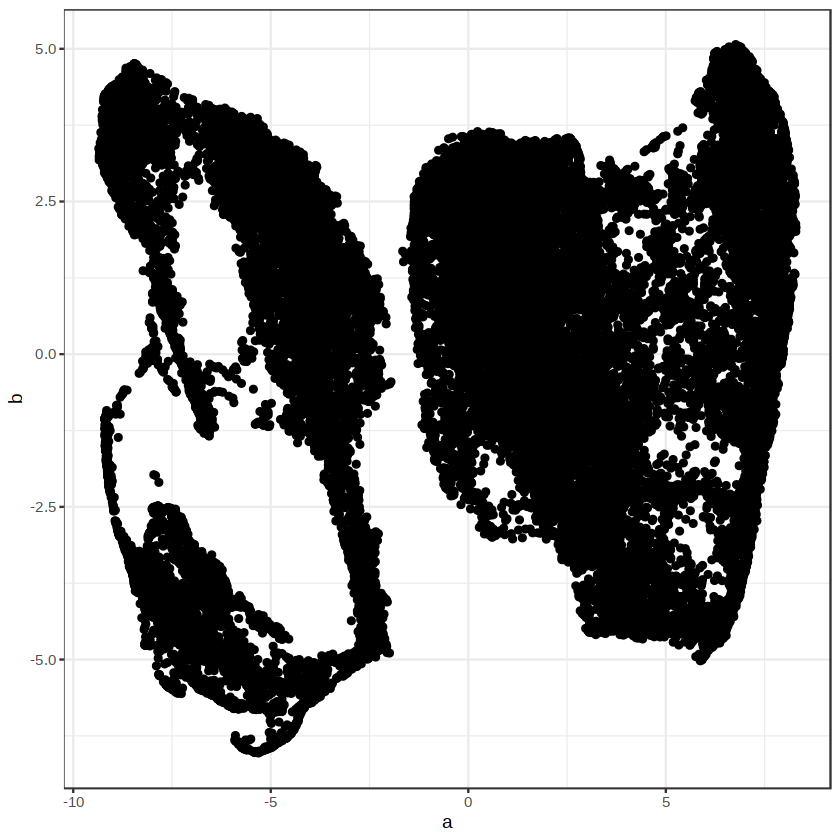

In [57]:
LSI = ArchR:::.computeLSI(mat = peakmatrix[stats[order(-var), feature][1:30000],]@assays@data$PeakMatrix, binarize=FALSE, nDimensions = 30, LSIMethod = 2)
umap = umap(LSI$matSVD[,1:25])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

In [ ]:
LSI = ArchR:::.computeLSI(mat = peakmatrix[stats[order(-var), feature][1:30000],]@assays@data$PeakMatrix, binarize=FALSE, nDimensions = 30, LSIMethod = 3)
umap = umap(LSI$matSVD[,1:25])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

## Lower resolution clusters

In [8]:
head(cell_metadata.dt)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC,Clusters_TileMatrix0.5,Clusters_TileMatrix_genotype,Clusters_PeakMatrix2,Clusters_PeakMatrix_genotype,Clusters_PeakMatrix2.1
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<int>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_wt_rep1,D3,wt,⋯,0.22,1.19,49080,0.02,TRUE,C2,C2wt,C11,C11wt,C11
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_wt_rep1,D3,wt,⋯,0.17,1.56,46497,0.02,TRUE,C2,C2wt,C11,C11wt,C11
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_wt_rep1,D3,wt,⋯,0.25,1.27,83426,0.02,TRUE,C2,C2wt,C11,C11wt,C11
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_wt_rep1,D3,wt,⋯,0.21,1.48,30196,0.02,TRUE,C2,C2wt,C11,C11wt,C11
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,3632,8276,4.60,8.16,day3_wt_rep1,D3,wt,⋯,0.21,1.48,13455,0.02,TRUE,C2,C2wt,C11,C11wt,C11
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,4878,15676,7.34,8.97,day3_wt_rep1,D3,wt,⋯,0.23,1.33,9315,0.02,TRUE,C2,C2wt,C11,C11wt,C11


In [12]:
# pseudobulk binarized matrix
atac.pb = aggregateAcrossCells(peakmatrix, id = cell_metadata.dt$Clusters_TileMatrix0.5, statistics='mean')

In [13]:
norm = log2(1e6*(sweep(atac.pb@assays@data$counts,2,colSums(atac.pb@assays@data$counts,na.rm=T),"/"))+1)

In [14]:
stats = data.table(idx = rowData(peakmatrix)$idx,
                  var = rowVars(norm),
                  mean = rowMeans(norm))

In [16]:
args$atac_matrix_cells <- '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds'

atac_cells.se <- readRDS(args$atac_matrix_cells)[,cell_metadata.dt$cell]
atac_cells.se
stats$feature = rownames(atac_cells.se)
rownames(peakmatrix) = rownames(atac_cells.se) 

class: RangedSummarizedExperiment 
dim: 238993 35536 
metadata(0):
assays(1): PeakMatrix
rownames(238993): chr1:3003473-3004073 chr1:3035580-3036180 ...
  chrX:169923276-169923876 chrX:169925415-169926015
rowData names(1): idx
colnames(35536): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [17]:
umap = fread(file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_None/umap_nfeatures25000_dims20_nneighbour25_mindist0.3.txt.gz'))
plot_acc = function(peak='chr1:3003473-3004073'){
    umap2 = cbind(umap, as.vector(assay(peakmatrix[peak, ])))
    umap2 = umap2[order(V2)]
    ggplot(umap2, aes(umap1, umap2, col=V2)) + 
        geom_point() + 
        viridis::scale_color_viridis(end=0, begin=1) + 
        theme_void()
}

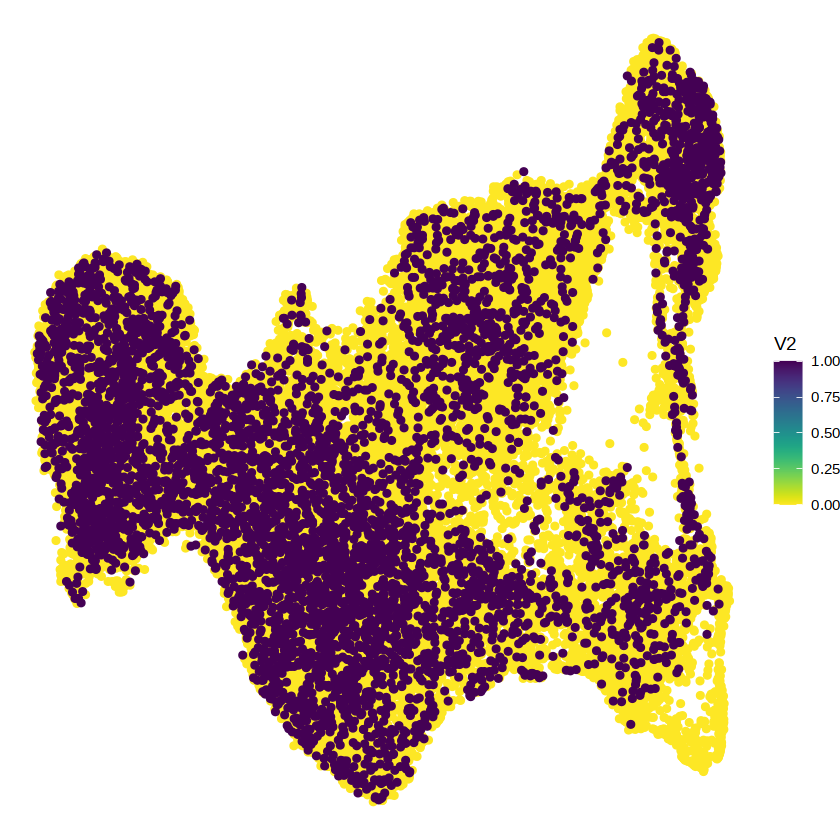

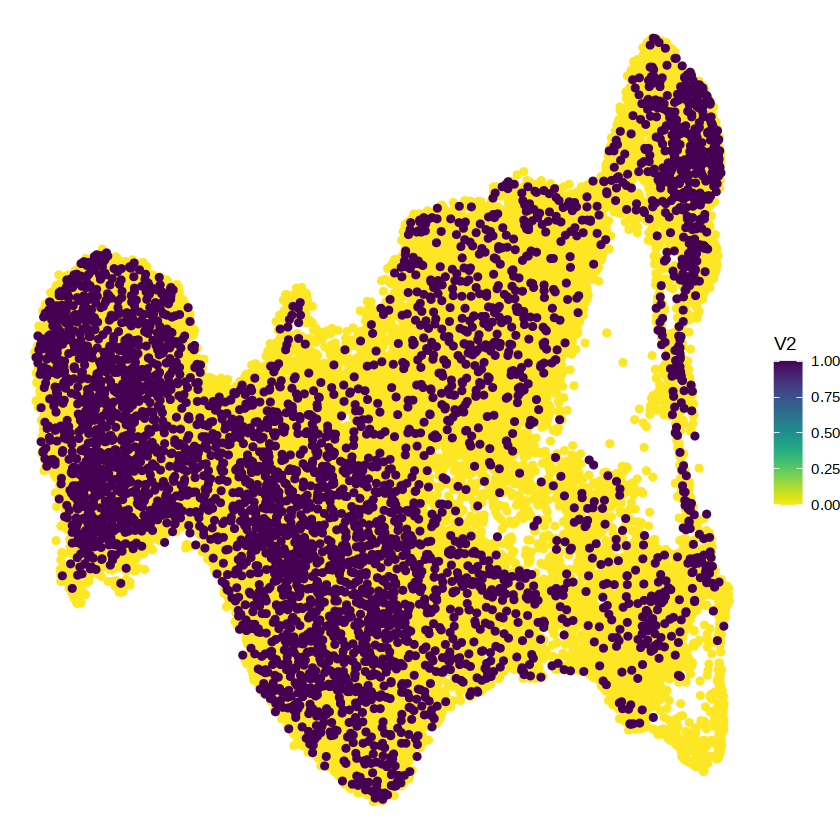

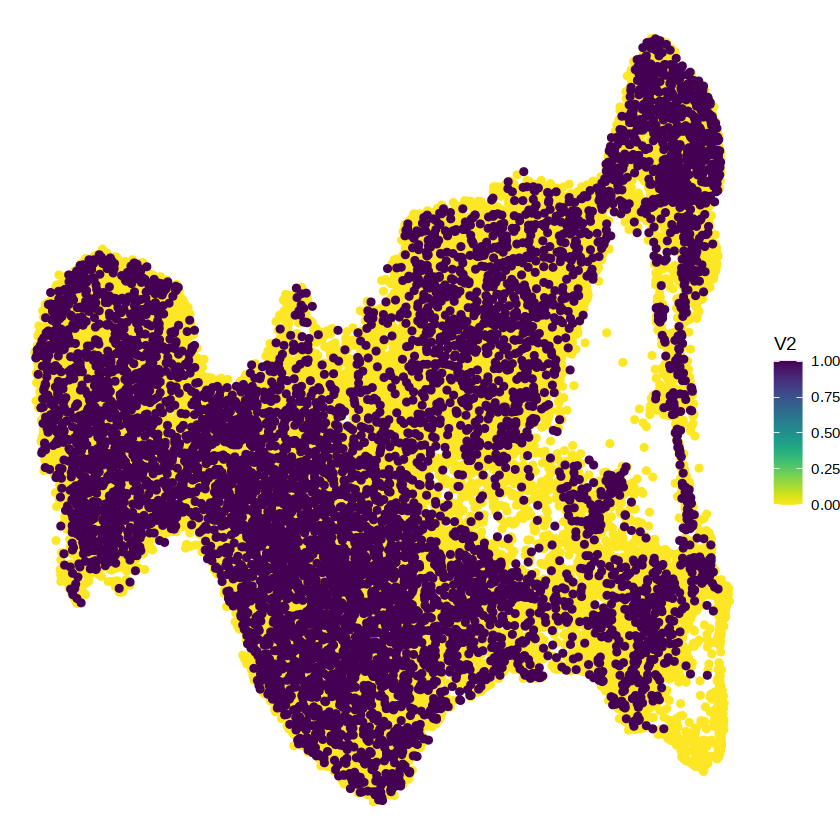

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


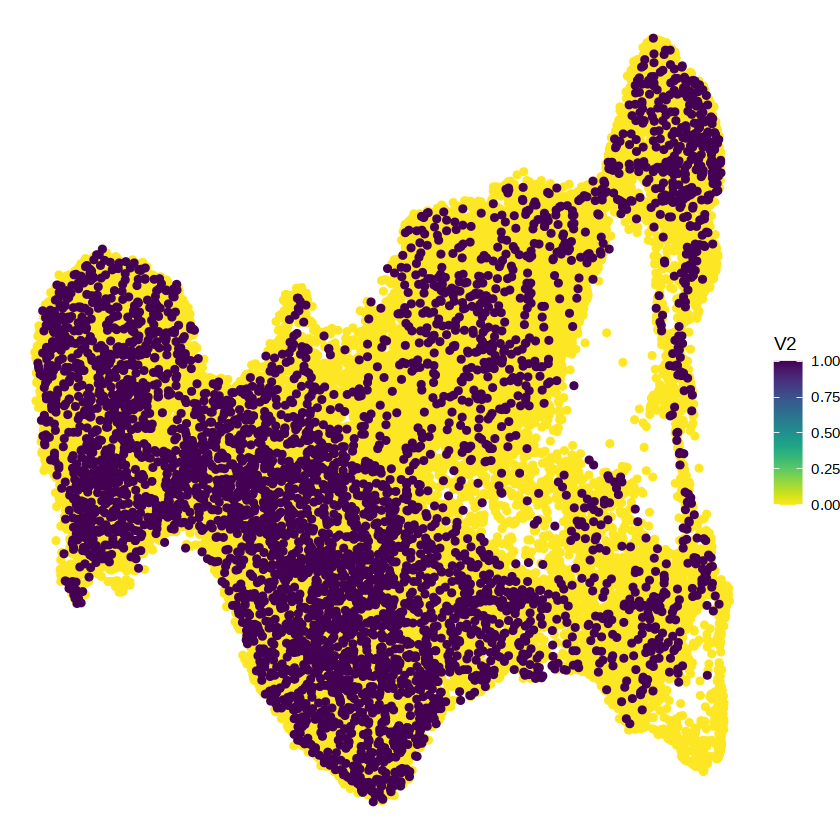

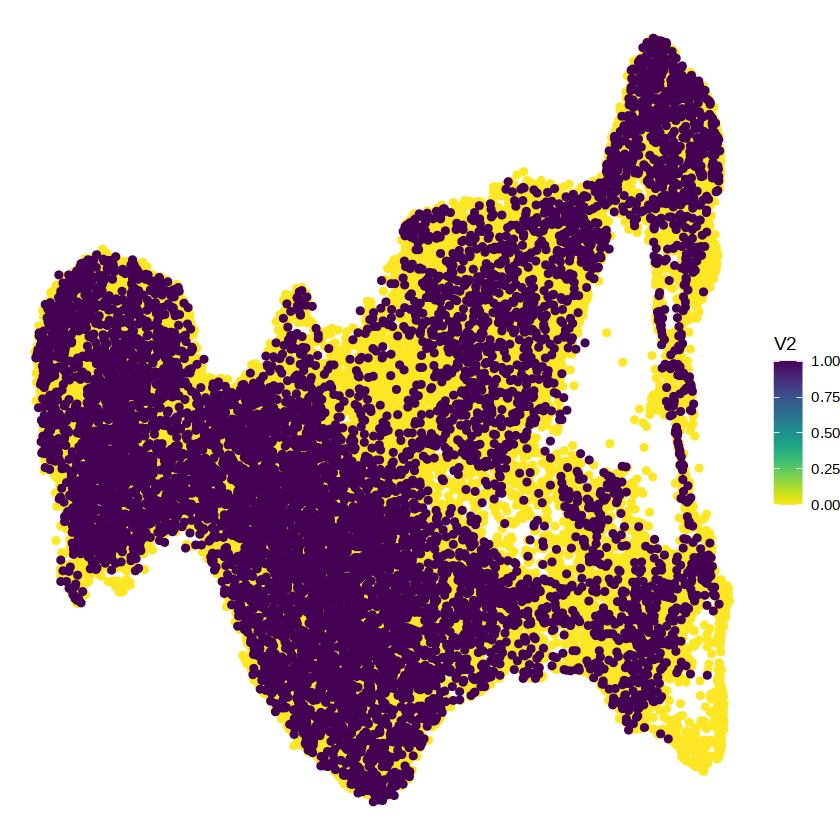

In [18]:
lapply(stats[order(-var), feature][1:5], plot_acc)

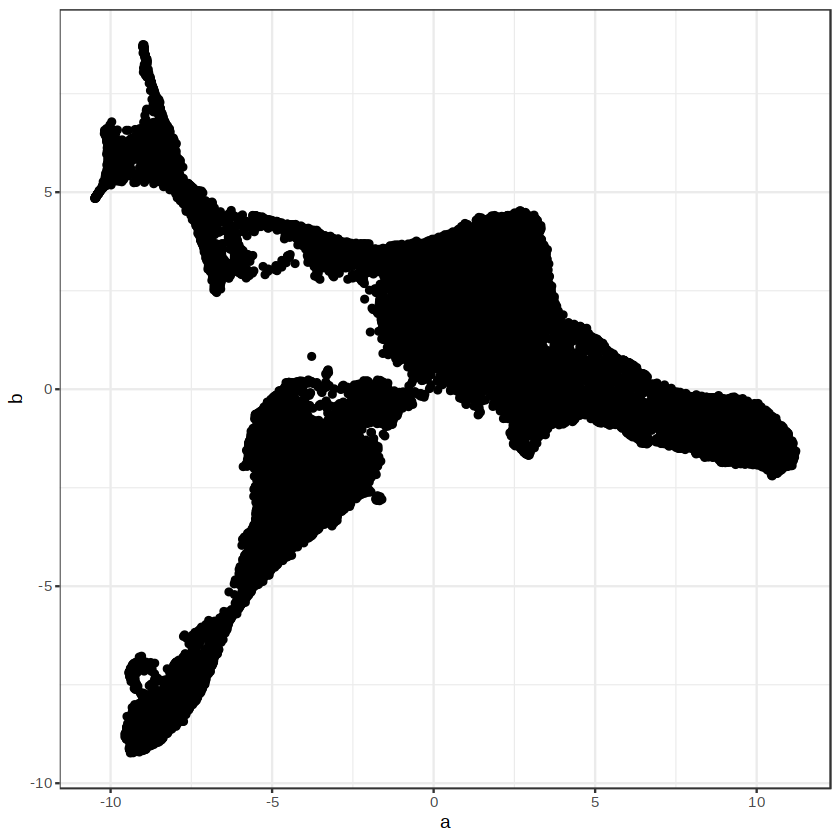

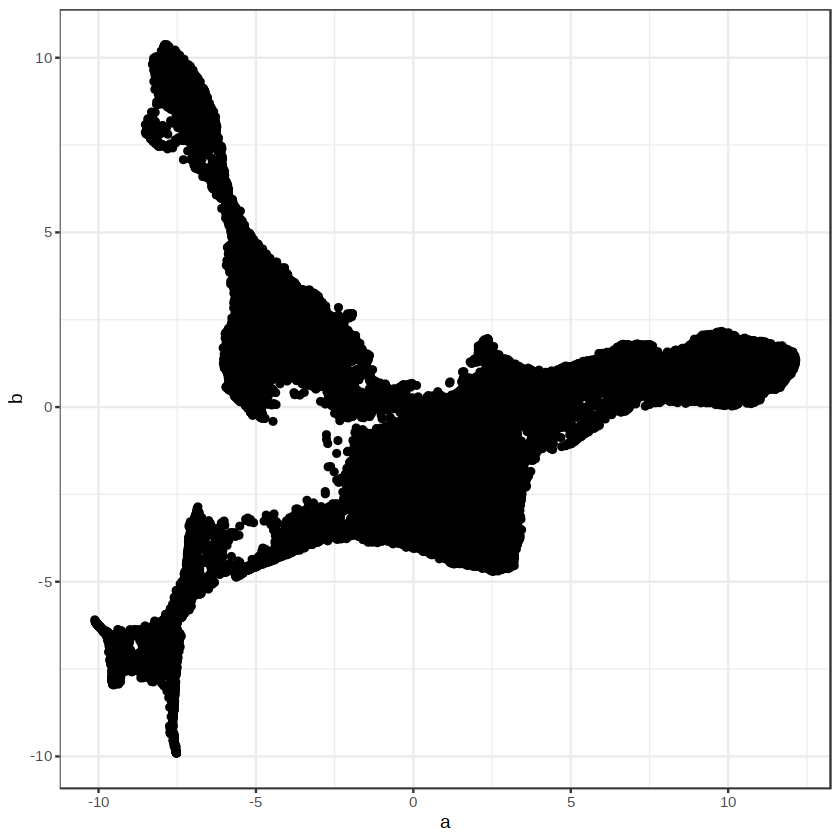

In [19]:
# shape of umap mostly influenced by TF-IDF method being the wrong one
LSI = ArchR:::.computeLSI(mat = peakmatrix[stats[order(-var), feature][1:25000],]@assays@data$PeakMatrix, binarize=FALSE, nDimensions = 30)
umap = umap(LSI$matSVD[,1:25])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

umap = umap(LSI$matSVD[,1:15])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

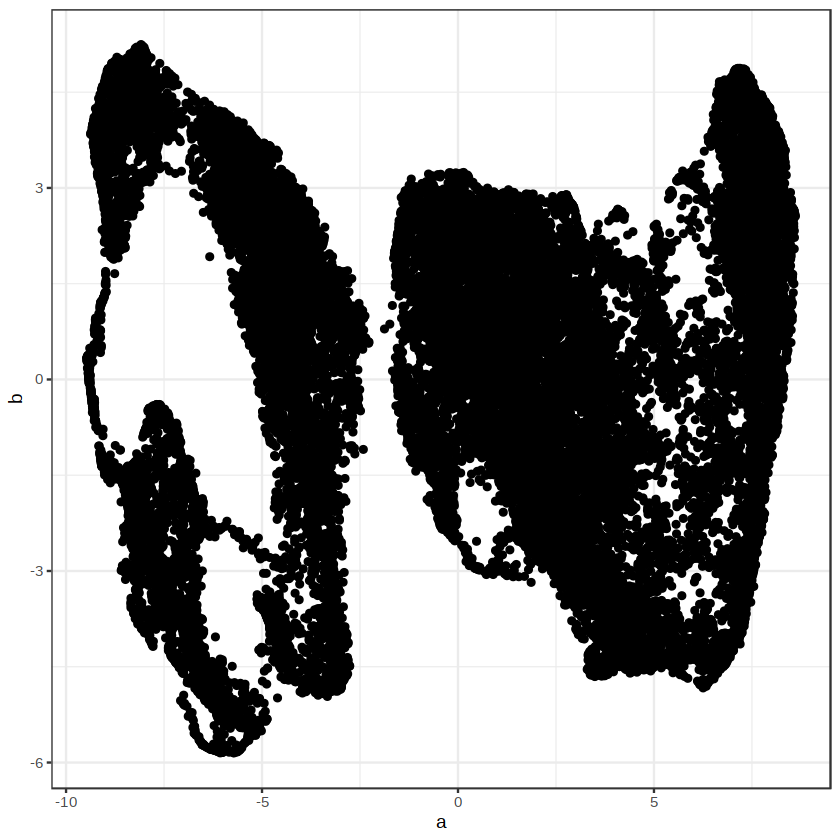

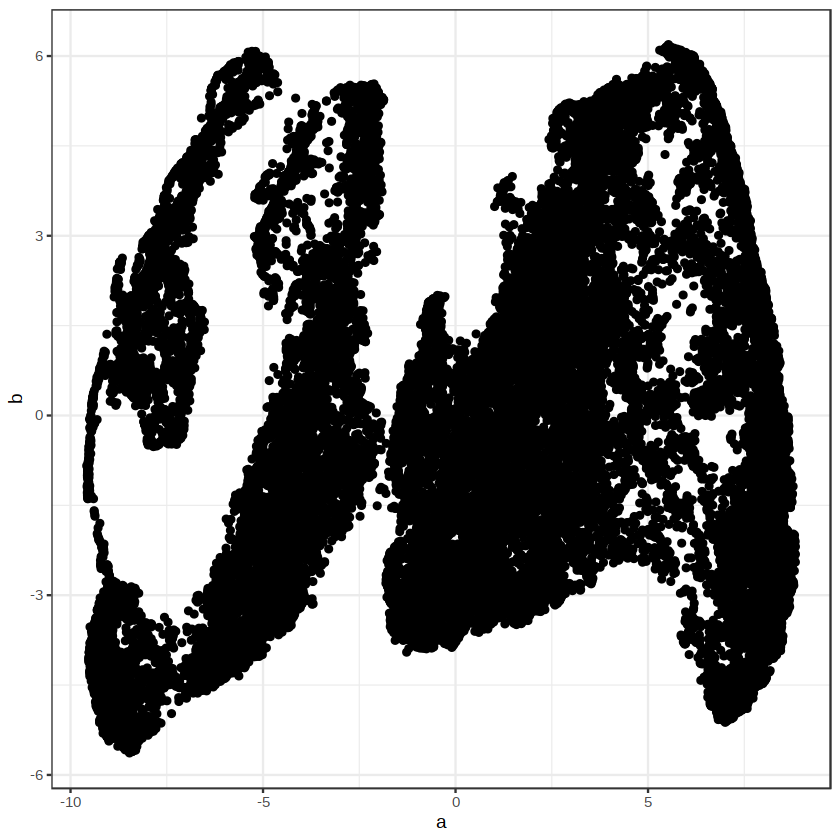

In [20]:
LSI = ArchR:::.computeLSI(mat = peakmatrix[stats[order(-var), feature][1:25000],]@assays@data$PeakMatrix, binarize=FALSE, nDimensions = 30, LSIMethod = 2)
umap = umap(LSI$matSVD[,1:25])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

umap = umap(LSI$matSVD[,1:15])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

# VarFeatures on non-binarized matrix, LSI on binarized

In [4]:
peakmatrix.nonbinarized = getMatrixFromProject(ArchRProject, useMatrix = "PeakMatrix",binarize =FALSE, threads =14)

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-dcda3b3dcc1d-Date-2023-01-31_Time-10-22-00.log
If there is an issue, please report to github with logFile!

2023-01-31 10:23:18 : Organizing colData, 1.314 mins elapsed.

2023-01-31 10:23:19 : Organizing rowData, 1.328 mins elapsed.

2023-01-31 10:23:19 : Organizing rowRanges, 1.328 mins elapsed.

2023-01-31 10:23:19 : Organizing Assays (1 of 1), 1.328 mins elapsed.

2023-01-31 10:24:33 : Constructing SummarizedExperiment, 2.553 mins elapsed.

2023-01-31 10:25:23 : Finished Matrix Creation, 3.394 mins elapsed.



In [5]:
peakmatrix.binarized = getMatrixFromProject(ArchRProject, useMatrix = "PeakMatrix",binarize =TRUE, threads =14)

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-dcda724d2b16-Date-2023-01-31_Time-10-28-14.log
If there is an issue, please report to github with logFile!

2023-01-31 10:29:37 : Organizing colData, 1.379 mins elapsed.

2023-01-31 10:29:44 : Organizing rowData, 1.504 mins elapsed.

2023-01-31 10:29:44 : Organizing rowRanges, 1.506 mins elapsed.

2023-01-31 10:29:44 : Organizing Assays (1 of 1), 1.509 mins elapsed.

2023-01-31 10:31:03 : Constructing SummarizedExperiment, 2.822 mins elapsed.

2023-01-31 10:31:53 : Finished Matrix Creation, 3.647 mins elapsed.



In [6]:
peakmatrix.binarized@assays@data$counts = peakmatrix.binarized@assays@data$PeakMatrix
peakmatrix.nonbinarized@assays@data$counts = peakmatrix.nonbinarized@assays@data$PeakMatrix

In [7]:
library(scuttle)

In [8]:
# pseudobulk binarized matrix
atac.pb = aggregateAcrossCells(peakmatrix.nonbinarized, id = cell_metadata.dt$Clusters_PeakMatrix2, statistics='mean')

In [9]:
norm = log2(1e6*(sweep(atac.pb@assays@data$counts,2,colSums(atac.pb@assays@data$counts,na.rm=T),"/"))+1)

In [11]:
stats = data.table(idx = rowData(peakmatrix.nonbinarized)$idx,
                  var = rowVars(norm),
                  mean = rowMeans(norm))

In [12]:
args$atac_matrix_cells <- '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds'

atac_cells.se <- readRDS(args$atac_matrix_cells)[,cell_metadata.dt$cell]
stats$feature = rownames(atac_cells.se)
rownames(peakmatrix.binarized) = rownames(atac_cells.se) 
rownames(peakmatrix.nonbinarized) = rownames(atac_cells.se) 

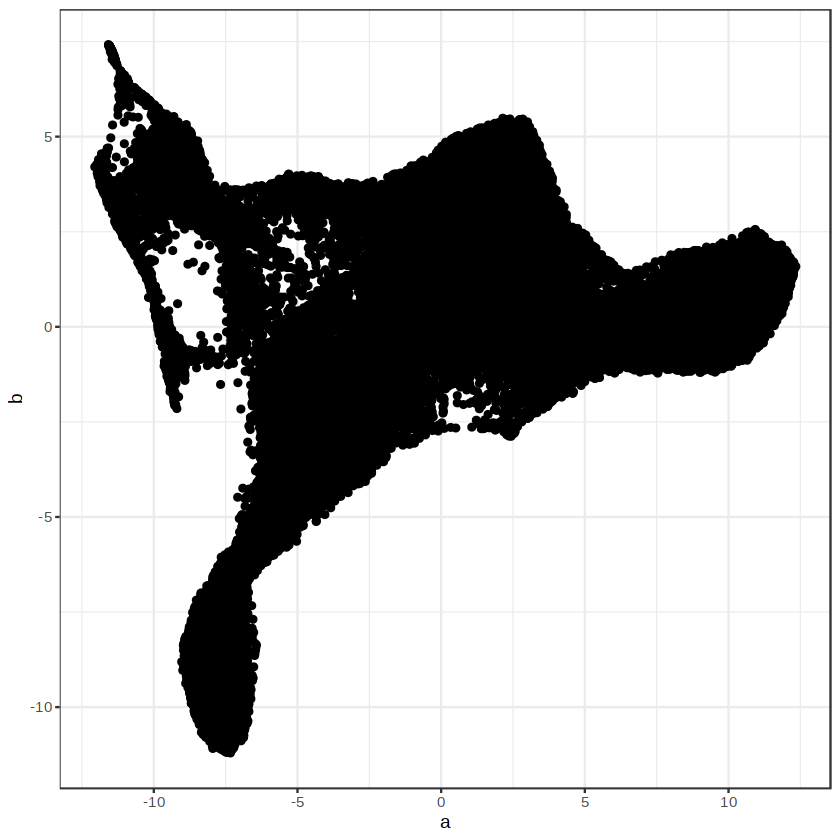

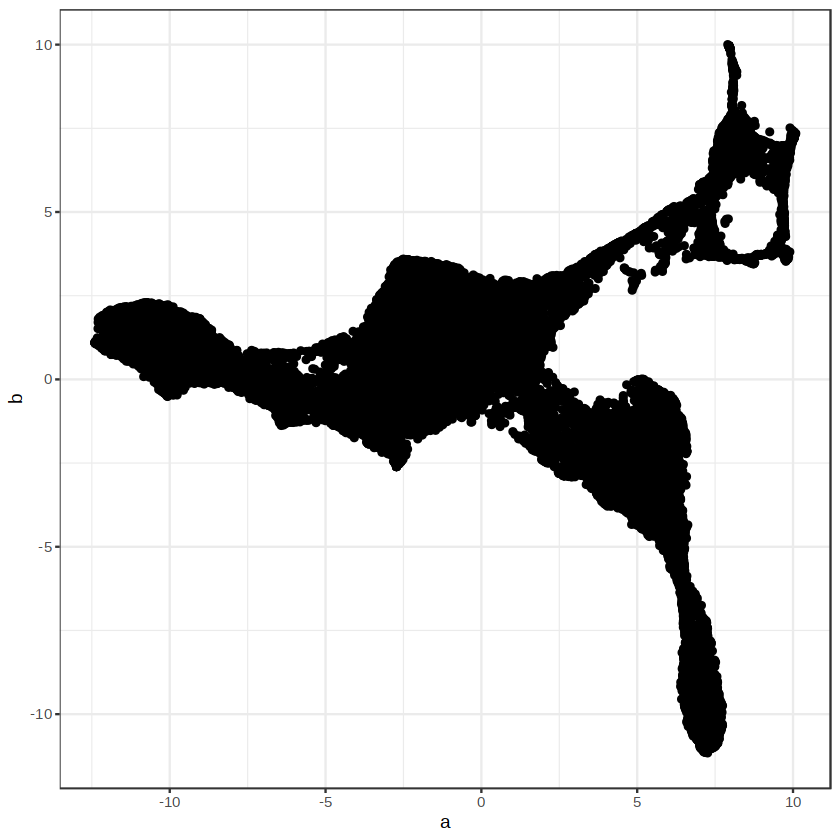

In [13]:
# shape of umap mostly influenced by TF-IDF method being the wrong one
LSI = ArchR:::.computeLSI(mat = peakmatrix.binarized[stats[order(-var), feature][1:25000],]@assays@data$PeakMatrix, nDimensions = 30)
umap = umap(LSI$matSVD[,1:25], n_neighbors=25, min_dist=0.3)

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

umap = umap(LSI$matSVD[,1:15])

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

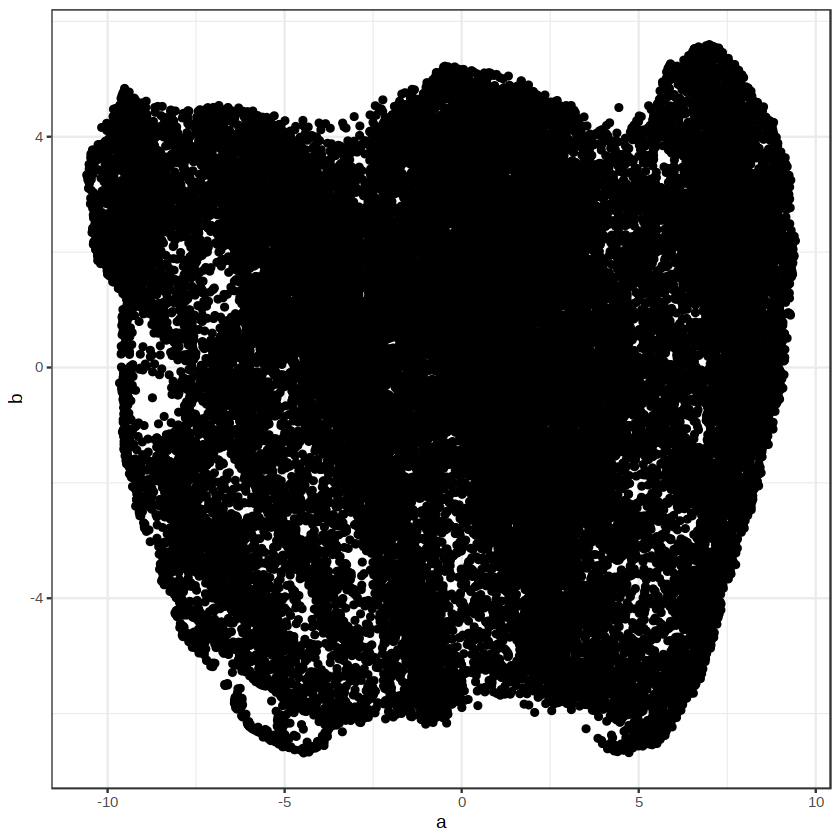

In [15]:
LSI = ArchR:::.computeLSI(mat = peakmatrix.binarized[stats[order(-var), feature][1:25000],]@assays@data$PeakMatrix, nDimensions = 30, LSIMethod=2)
umap = umap(LSI$matSVD[,1:25], n_neighbors=25, min_dist=0.3)

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()


# try with Variable Features from iterativeLSI

In [74]:
LSI.in = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures25000_dims20.rds')

In [75]:
Features = as.data.table(LSI.in$LSIFeatures) %>%
    .[,feature:=paste0(seqnames, ':', start, '-', end)] %>% .[,feature]
head(Features)

[1] "chr1:3191587-3192187" "chr1:3671508-3672108" "chr1:4492446-4493046"
[4] "chr1:4493263-4493863" "chr1:4496233-4496833" "chr1:4571659-4572259"

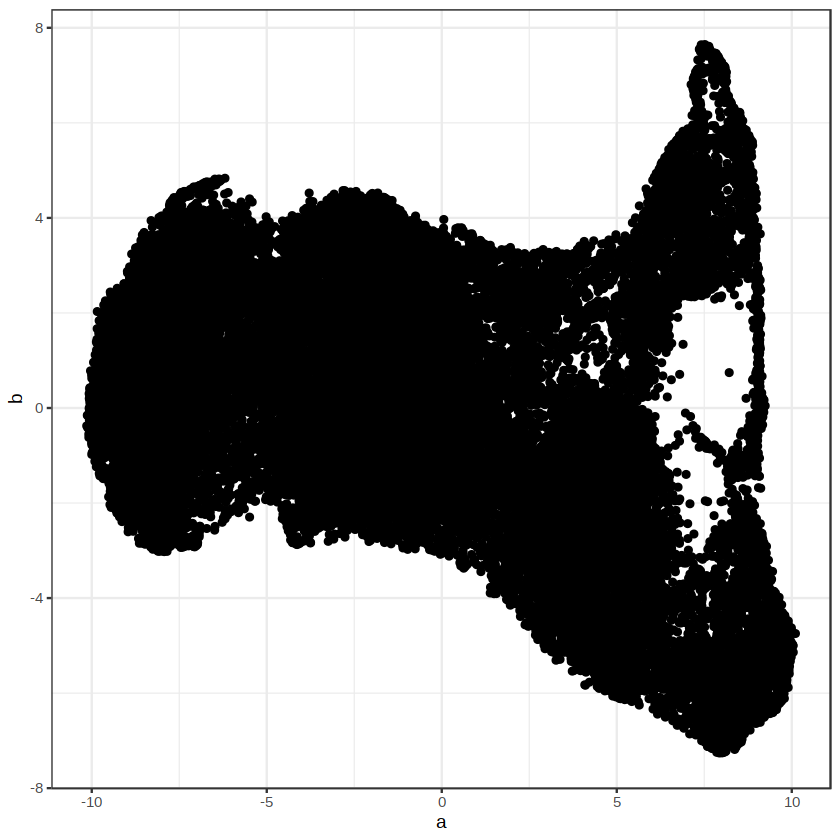

In [76]:
LSI = ArchR:::.computeLSI(mat = peakmatrix.nonbinarized[Features,]@assays@data$PeakMatrix, 
                          nDimensions = 20,
                          LSIMethod = 2,
                          scaleTo = 10000,
                          binarize=TRUE,
                          outlierQuantiles = c(0.02, 0.98),
                          seed = 1,
                          tstart = Sys.time()
                         )
umap = umap(LSI$matSVD, 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

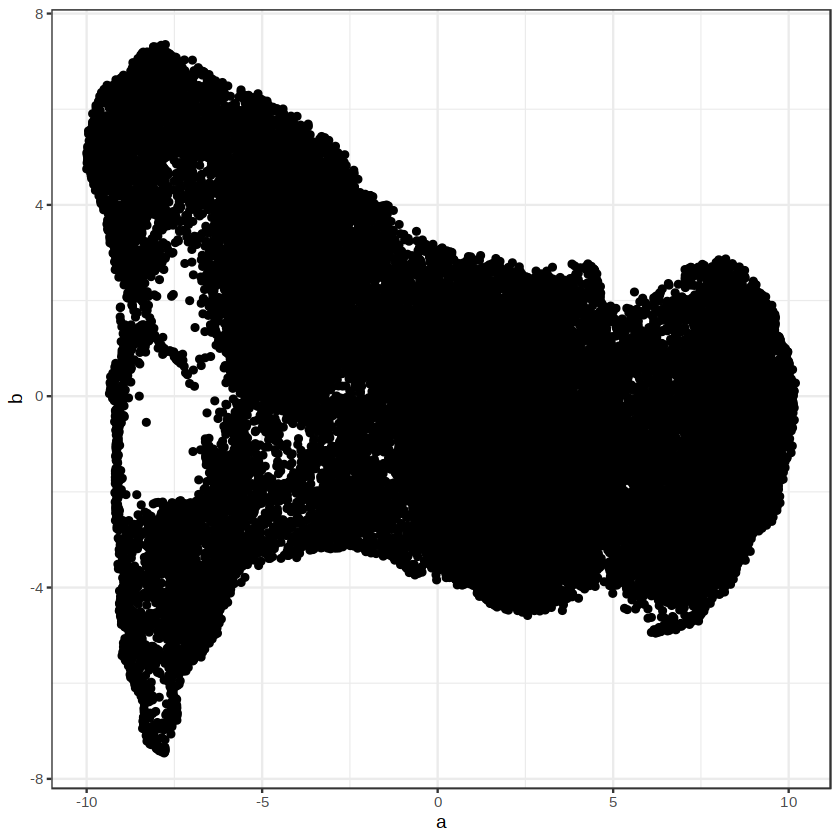

In [77]:
# Scale LSIs
LSI.scaled = scale(LSI$matSVD)
umap = umap(LSI.scaled, 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

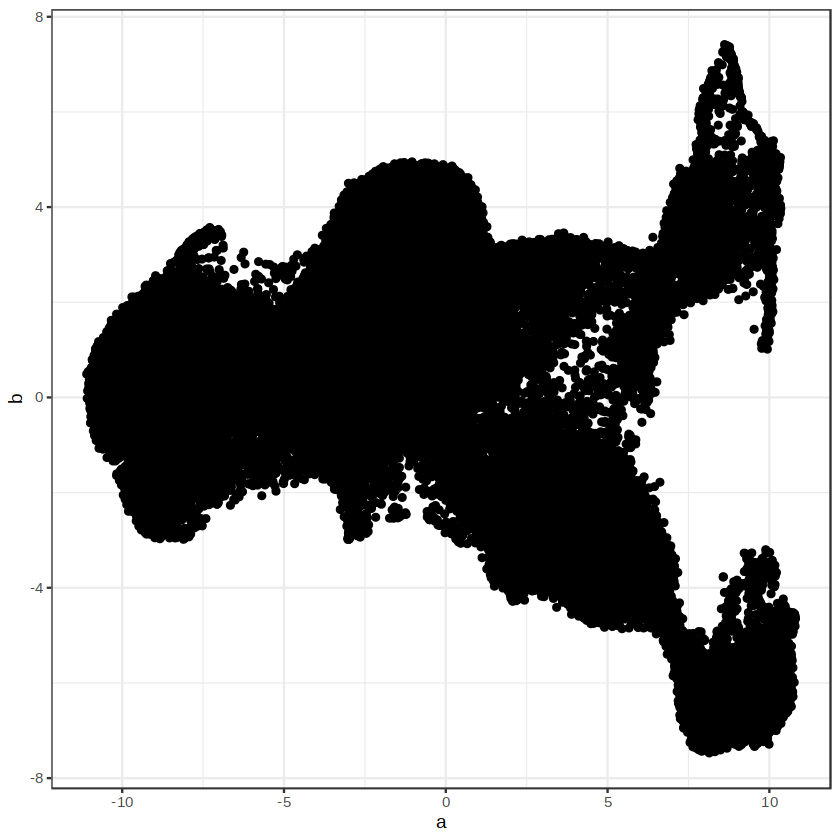

In [78]:
LSI = ArchR:::.computeLSI(mat = peakmatrix.nonbinarized[Features,]@assays@data$PeakMatrix, 
                          nDimensions = 20,
                          LSIMethod = 1,
                          scaleTo = 10000,
                          binarize=TRUE,
                          outlierQuantiles = c(0.02, 0.98),
                          seed = 1,
                          tstart = Sys.time()
                         )
umap = umap(LSI$matSVD, 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

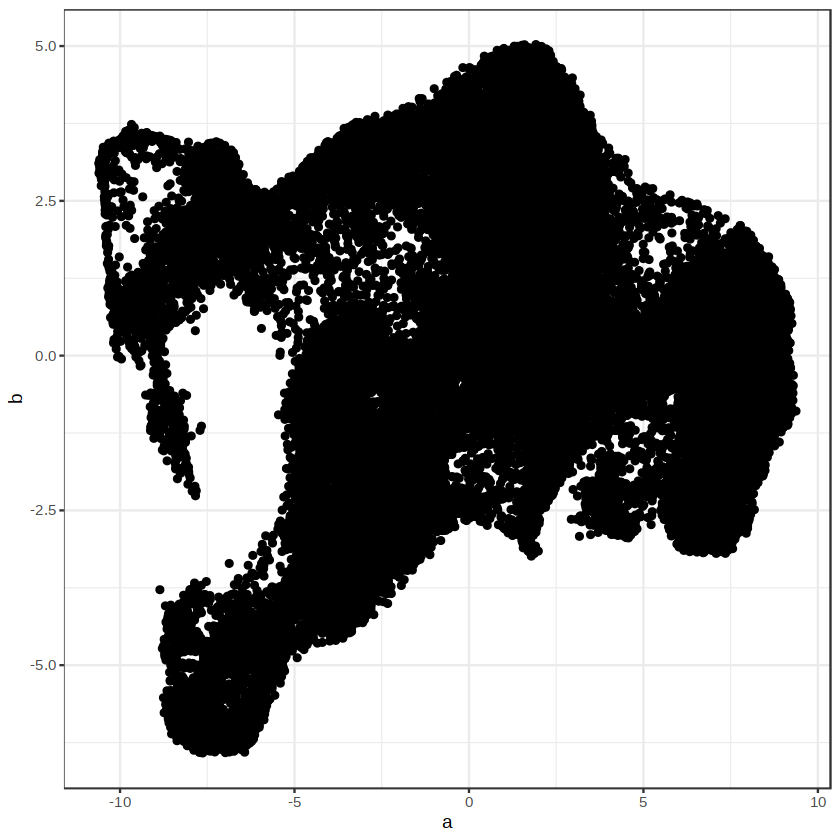

In [95]:
# Scale LSIs
LSI.scaled = scale(LSI$matSVD)
umap = umap(LSI.scaled, 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

In [82]:
# Correlate with depth of actual matrix used
depth = colSums(peakmatrix.nonbinarized@assays@data$PeakMatrix)

In [88]:
# Remove LSIs correlated with readDepth
cor = abs(apply(LSI.scaled, 2, cor, y=depth))
cor

LSI1        LSI2        LSI3        LSI4        LSI5        LSI6 
0.395400322 0.231769540 0.156434811 0.179289711 0.785226897 0.104738186 
       LSI7        LSI8        LSI9       LSI10       LSI11       LSI12 
0.105285057 0.231096542 0.116078130 0.070533822 0.003555127 0.108681841 
      LSI13       LSI14       LSI15       LSI16       LSI17       LSI18 
0.040903005 0.098738297 0.040989809 0.046120178 0.023736637 0.094374938 
      LSI19       LSI20 
0.053356241 0.004305432

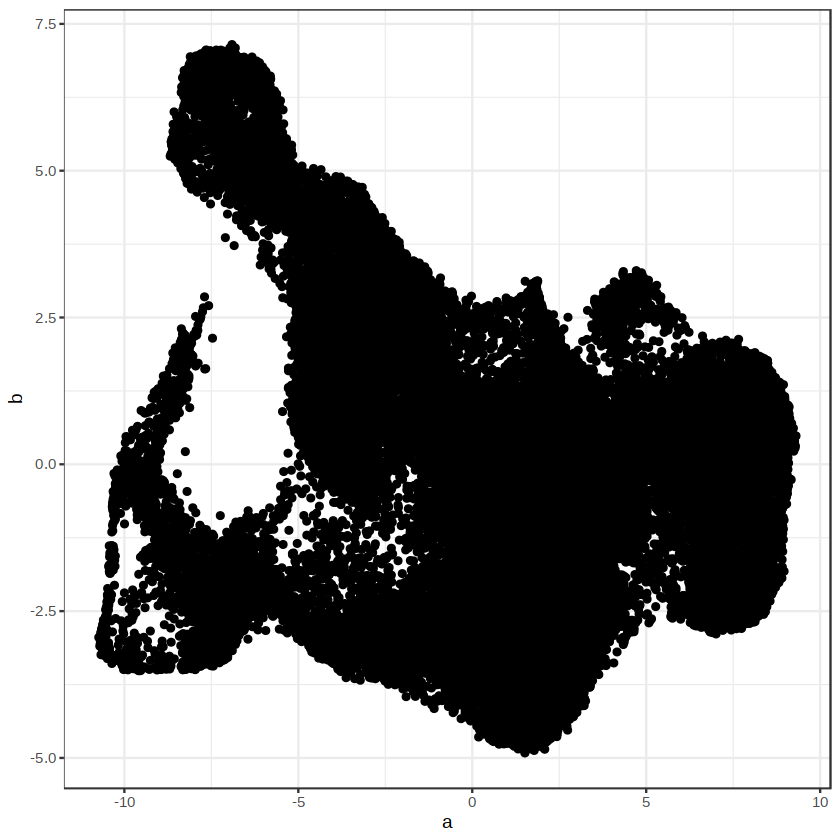

In [97]:
# Scale LSIs
LSI.scaled = scale(LSI$matSVD)
umap = umap(LSI.scaled[,-5], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

# Final implementation of everything

In [98]:
LSI = ArchR:::.computeLSI(mat = peakmatrix.nonbinarized[Features,]@assays@data$PeakMatrix, 
                          nDimensions = 20,
                          LSIMethod = 2,
                          scaleTo = 10000,
                          binarize=TRUE,
                          outlierQuantiles = c(0.02, 0.98),
                          seed = 1,
                          tstart = Sys.time()
                         )


In [106]:
LSI.scaled = scale(LSI$matSVD)

In [107]:
# Remove LSIs correlated with readDepth
cor = abs(apply(LSI.scaled, 2, cor, y=log10(depth + 1)))
cor

LSI1        LSI2        LSI3        LSI4        LSI5        LSI6 
0.994356214 0.231690415 0.108489650 0.326856800 0.618291946 0.017599997 
       LSI7        LSI8        LSI9       LSI10       LSI11       LSI12 
0.112178625 0.135174104 0.123342755 0.098101548 0.065579811 0.074034993 
      LSI13       LSI14       LSI15       LSI16       LSI17       LSI18 
0.074574101 0.005941739 0.062690147 0.063011118 0.025124121 0.053559919 
      LSI19       LSI20 
0.017743411 0.021633553

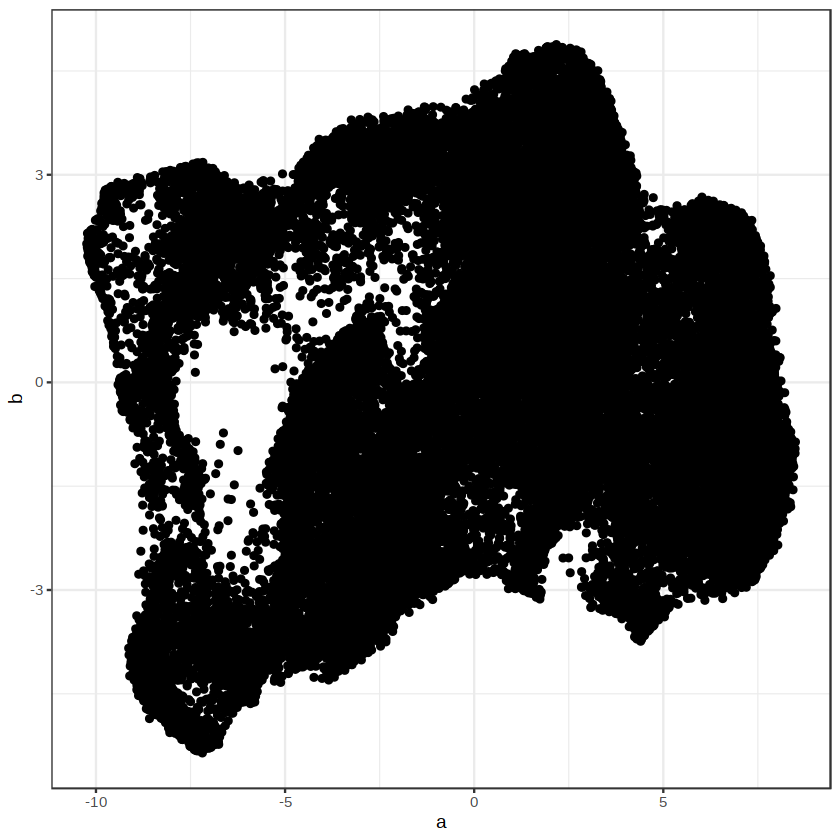

In [103]:
umap = umap(LSI.scaled[,-c(1, 5)], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

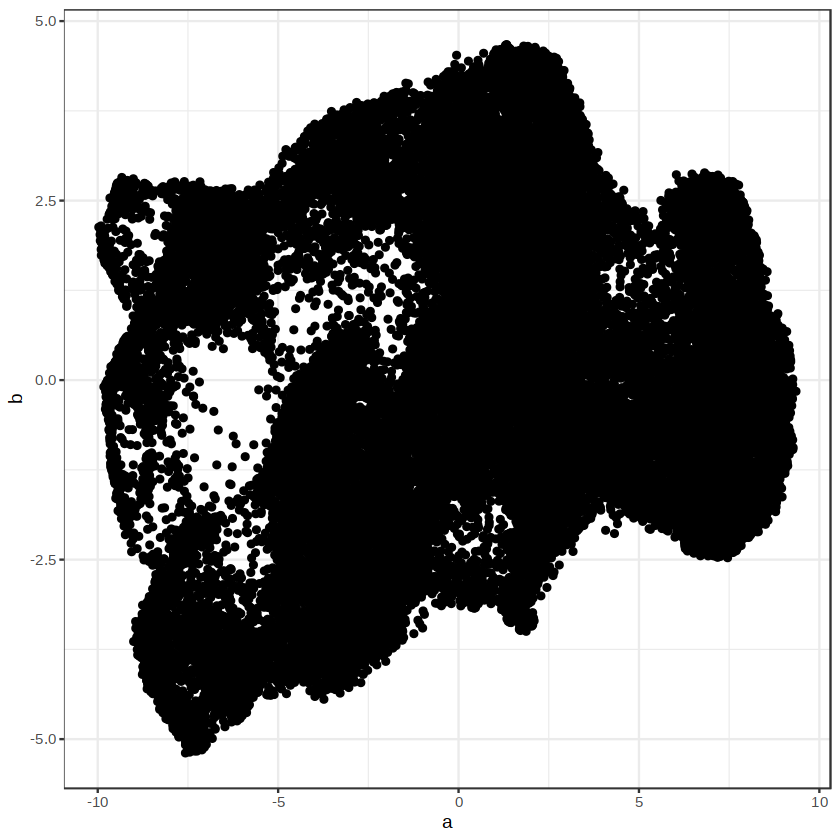

In [104]:
umap = umap(LSI.scaled[,-c(1)], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

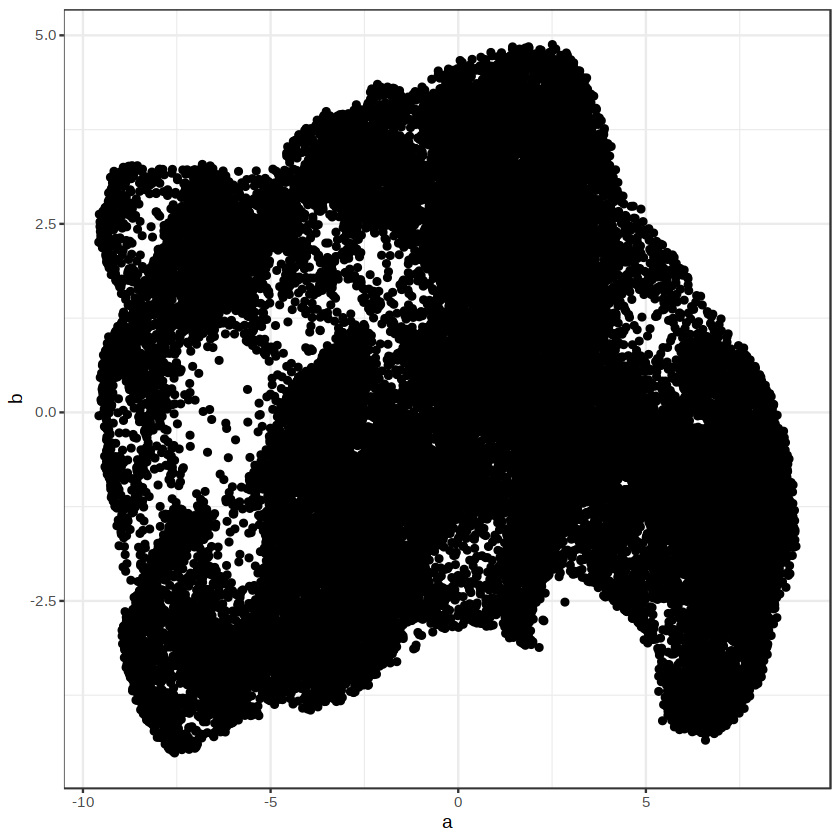

In [105]:
# Cap scaled LSI
LSI.scaled[LSI.scaled>2] <- 2
LSI.scaled[LSI.scaled<(-2)] <- (-2)

umap = umap(LSI.scaled[,-c(1)], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

In [108]:
LSI = ArchR:::.computeLSI(mat = peakmatrix.nonbinarized[Features,]@assays@data$PeakMatrix, 
                          nDimensions = 20,
                          LSIMethod = 1,
                          scaleTo = 10000,
                          binarize=TRUE,
                          outlierQuantiles = c(0.02, 0.98),
                          seed = 1,
                          tstart = Sys.time()
                         )


In [109]:
LSI.scaled = scale(LSI$matSVD)

In [112]:
# Remove LSIs correlated with readDepth
cor = abs(apply(LSI.scaled, 2, cor, y=log10(depth + 1)))
cor

LSI1        LSI2        LSI3        LSI4        LSI5        LSI6 
0.303134974 0.156902561 0.159707284 0.155132870 0.749269716 0.101343820 
       LSI7        LSI8        LSI9       LSI10       LSI11       LSI12 
0.132216750 0.241765148 0.162929600 0.116009082 0.041551234 0.154326121 
      LSI13       LSI14       LSI15       LSI16       LSI17       LSI18 
0.022432789 0.108260111 0.062441939 0.104105388 0.014958621 0.084433478 
      LSI19       LSI20 
0.056710778 0.007399016

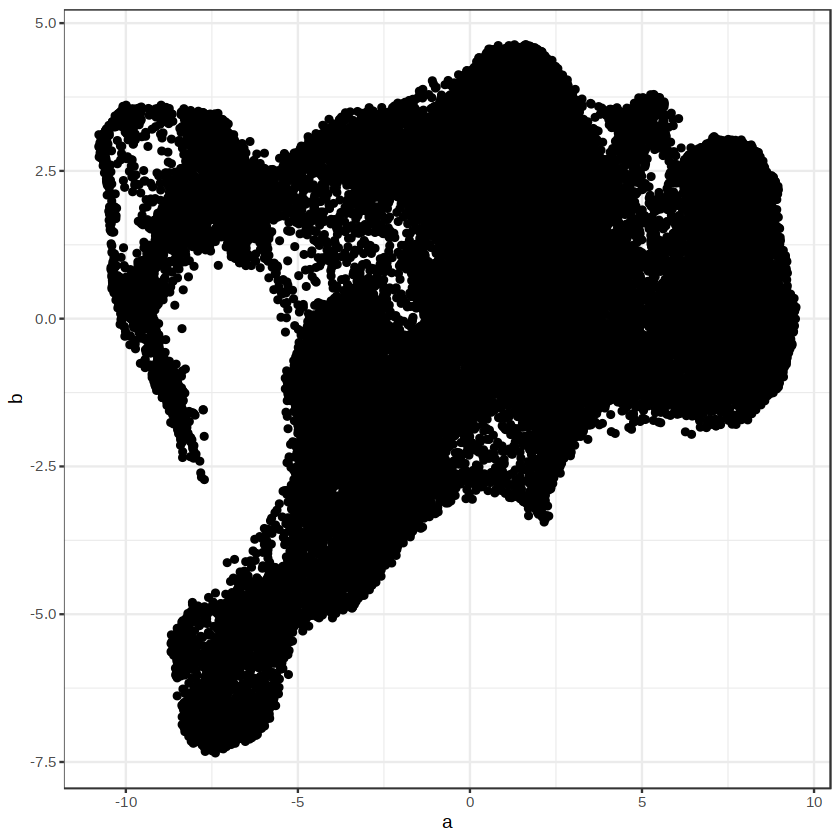

In [113]:
umap = umap(LSI.scaled[,-5], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

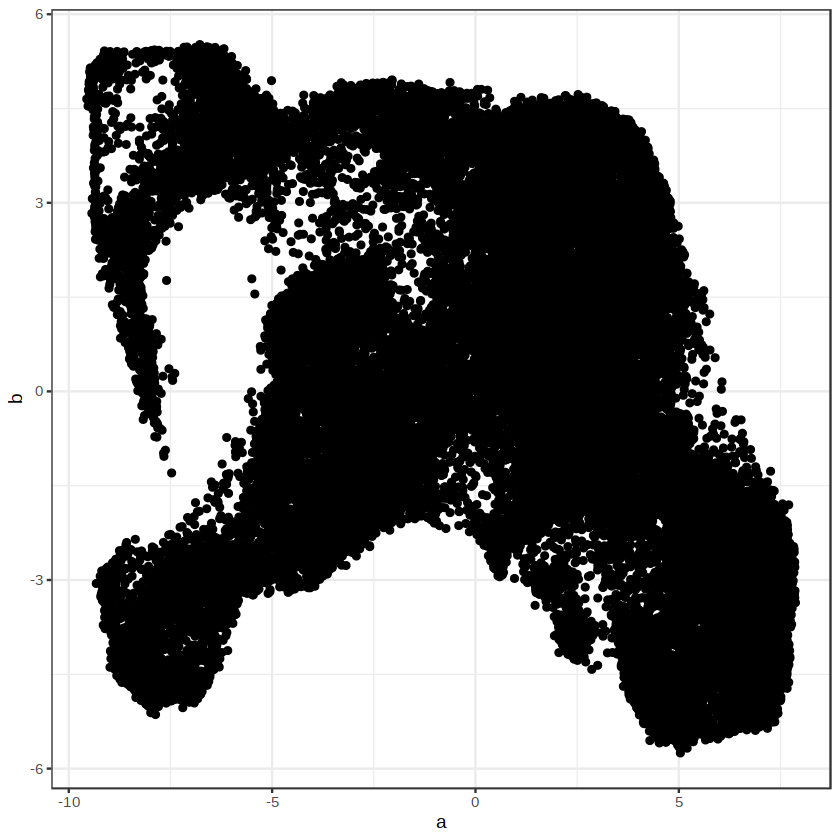

In [114]:
# Cap scaled LSI
LSI.scaled[LSI.scaled>2] <- 2
LSI.scaled[LSI.scaled<(-2)] <- (-2)

umap = umap(LSI.scaled[,-c(5)], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

### not Binarized

In [123]:
LSI = ArchR:::.computeLSI(mat = peakmatrix.nonbinarized[Features,]@assays@data$PeakMatrix, 
                          nDimensions = 20,
                          LSIMethod = 1,
                          scaleTo = 10000,
                          binarize=FALSE,
                          outlierQuantiles = c(0.02, 0.98),
                          seed = 1,
                          tstart = Sys.time()
                         )


In [124]:
LSI.scaled = scale(LSI$matSVD)

In [125]:
# Remove LSIs correlated with readDepth
cor = abs(apply(LSI.scaled, 2, cor, y=log10(depth + 1)))
cor

LSI1       LSI2       LSI3       LSI4       LSI5       LSI6       LSI7 
0.54115156 0.10837287 0.04520234 0.05024121 0.15644870 0.36923861 0.10209682 
      LSI8       LSI9      LSI10      LSI11      LSI12      LSI13      LSI14 
0.24384398 0.15189961 0.23406809 0.03325368 0.37162863 0.02586452 0.15675720 
     LSI15      LSI16      LSI17      LSI18      LSI19      LSI20 
0.07683653 0.05762732 0.18334953 0.05657335 0.13546417 0.04276218

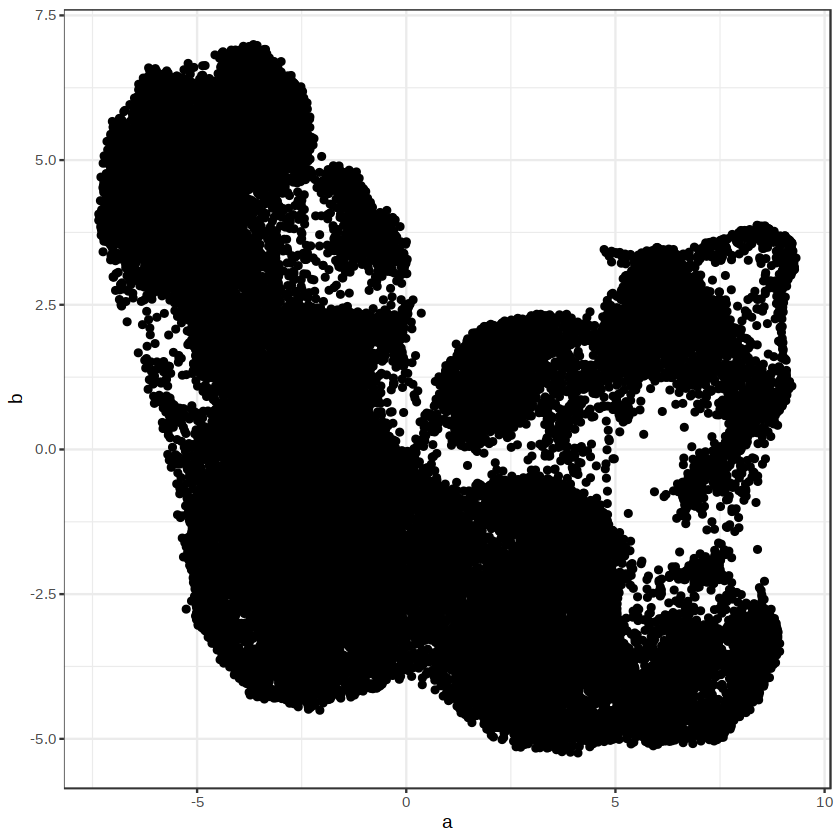

In [126]:
umap = umap(LSI.scaled[,-5], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

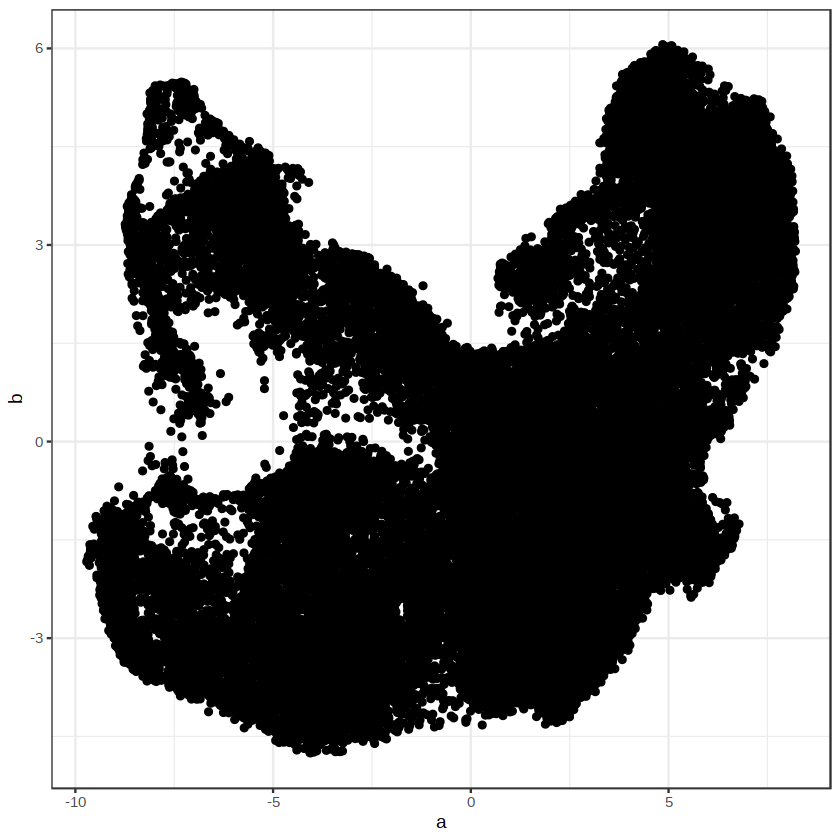

In [127]:
# Cap scaled LSI
LSI.scaled[LSI.scaled>2] <- 2
LSI.scaled[LSI.scaled<(-2)] <- (-2)

umap = umap(LSI.scaled[,-c(5)], 
            n_neighbors=25, 
            min_dist=0.3,
            metric = 'cosine')

colnames(umap) = c('a', 'b')
ggplot(as.data.frame(umap), aes(a,b)) + 
    geom_point() + 
    theme_bw()

# with exported PeakMatrix

In [115]:
Peak.mtx = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')

In [121]:
peakmatrix.nonbinarized@assays@data$counts[10000:10010,1:10]

  [[ suppressing 10 column names ‘2_Eo_DEG_G9_day3_5_VC#CTACGAAGTGAGCACT-1’, ‘2_Eo_DEG_G9_day3_5_VC#TGGACAAAGCTCAATA-1’, ‘2_Eo_DEG_G9_day3_5_VC#GTGAGCGAGCTCCTAC-1’ ... ]]



11 x 10 sparse Matrix of class "dgCMatrix"
                         
 [1,] . . . 2 . 2 . . . .
 [2,] 2 . . . . . 2 1 . 1
 [3,] 2 . 2 . 1 . . 1 . .
 [4,] . . 4 . 2 . . . . .
 [5,] 1 . 2 . 2 3 2 . 4 .
 [6,] 1 . 2 1 . 2 . 2 1 .
 [7,] 1 . . 3 . 1 . . 1 .
 [8,] . . . . 3 . . 1 . .
 [9,] . 2 . . . 2 . 2 3 .
[10,] 4 . . 1 4 2 . 2 3 2
[11,] 1 . 4 4 1 . 2 1 4 2

In [122]:
Peak.mtx@assays@data$PeakMatrix[10000:10010,1:10]

  [[ suppressing 10 column names ‘2_Eo_DEG_G9_day3_5_VC#CTACGAAGTGAGCACT-1’, ‘2_Eo_DEG_G9_day3_5_VC#TGGACAAAGCTCAATA-1’, ‘2_Eo_DEG_G9_day3_5_VC#GTGAGCGAGCTCCTAC-1’ ... ]]



11 x 10 sparse Matrix of class "dgCMatrix"
                         
 [1,] . . . 2 . 2 . . . .
 [2,] 2 . . . . . 2 1 . 1
 [3,] 2 . 2 . 1 . . 1 . .
 [4,] . . 4 . 2 . . . . .
 [5,] 1 . 2 . 2 3 2 . 4 .
 [6,] 1 . 2 1 . 2 . 2 1 .
 [7,] 1 . . 3 . 1 . . 1 .
 [8,] . . . . 3 . . 1 . .
 [9,] . 2 . . . 2 . 2 3 .
[10,] 4 . . 1 4 2 . 2 3 2
[11,] 1 . 4 4 1 . 2 1 4 2